### Step 0 — Setup
- **The dataset**

Before writing any code, we load and inspect the data. This is always the first step.

In [1]:
# Our dataset — 6 students, 4 variables each
import numpy as np

students    = [1, 2, 3, 4, 5, 6]
study_hours = [5, 8, 10, 12, 15, 18]
attendance  = [60, 75, 80, 85, 90, 95]
assignment  = [45, 58, 62, 70, 82, 90]
exam_score  = [48, 60, 67, 74, 85, 92]

print("Number of students:", len(students))

Number of students: 6


### Step 1 — Descriptive statistics
- **Explore and summarise**

Calculate the mean for each variable. Understand what is typical in this dataset.

In [2]:
# Calculate the mean (average) of each variable
mean_hours  = np.mean(study_hours)
mean_attend = np.mean(attendance)
mean_assign = np.mean(assignment)
mean_exam   = np.mean(exam_score)

print(f"Mean study hours:  {mean_hours:.2f}")
print(f"Mean attendance:   {mean_attend:.2f}%")
print(f"Mean assignment:   {mean_assign:.2f}")
print(f"Mean exam score:   {mean_exam:.2f}")

Mean study hours:  11.33
Mean attendance:   80.83%
Mean assignment:   67.83
Mean exam score:   71.00


### Step 2 — Spread
- **Measure variability**
  
Two datasets can have the same mean but be very different. Variability tells you how spread the data is.

In [11]:
# Variance — how spread out is the data?
var_hours = np.var(study_hours)
var_exam  = np.var(exam_score)

# Standard deviation — easier to interpret
std_hours = np.std(study_hours)
std_exam  = np.std(exam_score)

print(f"Study hours — range: {max(study_hours)-min(study_hours)}, std: {std_hours:.2f}")
print(f"Exam score  — range: {max(exam_score)-min(exam_score)},  std: {std_exam:.2f}")

Study hours — range: 13, std: 4.31
Exam score  — range: 44,  std: 14.79


Why this matters: A large standard deviation means students are very different from each other. A small one means they are more similar. Never report a mean without also reporting the spread.

### Step 3 — Charts
- **Visualise the data** 
  
Always visualise before modelling. Charts reveal what formulas cannot.

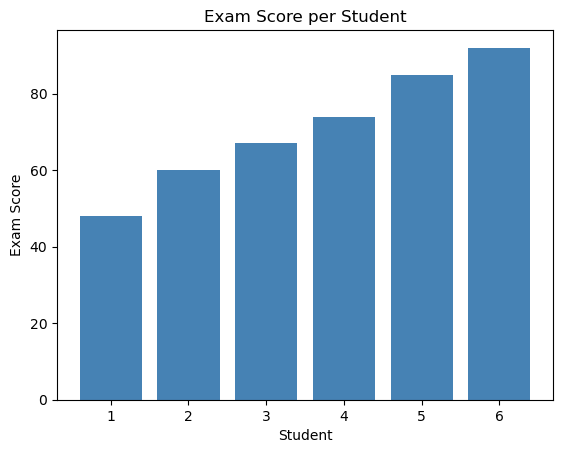

In [12]:
import matplotlib.pyplot as plt

# Histogram — distribution of exam scores
plt.bar(students, exam_score, color='steelblue')
plt.xlabel('Student')
plt.ylabel('Exam Score')
plt.title('Exam Score per Student')
plt.show()



What to look for: Is there an upward trend? (More study → higher score?) Are all points close to a line? (Strong relationship?) Any point far from the trend? (Outlier or unusual student?)

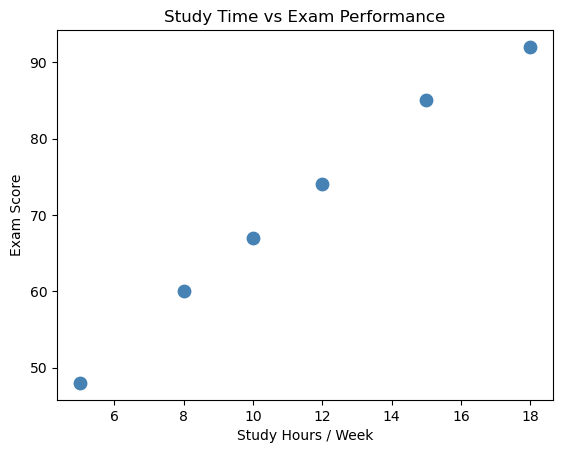

In [13]:
# Scatter — study hours vs exam score
plt.scatter(study_hours, exam_score, color='steelblue', s=80)
plt.xlabel('Study Hours / Week')
plt.ylabel('Exam Score')
plt.title('Study Time vs Exam Performance')
plt.show()

What to look for: Is there an upward trend? (More study → higher score?) Are all points close to a line? (Strong relationship?) Any point far from the trend? (Outlier or unusual student?)

### Step 4 — Correlation
- **Investigate relationships**
  
Correlation measures how strongly two variables move together. We calculate r for each pair.

In [5]:
# Pearson correlation coefficient r
# r = 1 → perfect positive relationship
# r = 0 → no relationship
# r = -1 → perfect negative relationship

r_hours  = np.corrcoef(study_hours, exam_score)[0,1]
r_attend = np.corrcoef(attendance, exam_score)[0,1]
r_assign = np.corrcoef(assignment, exam_score)[0,1]

print(f"Study hours vs Exam: r = {r_hours:.3f}")
print(f"Attendance  vs Exam: r = {r_attend:.3f}")
print(f"Assignment  vs Exam: r = {r_assign:.3f}")

Study hours vs Exam: r = 0.997
Attendance  vs Exam: r = 0.979
Assignment  vs Exam: r = 0.998


Correlation ≠ Causation. Ice cream sales and drowning both rise in summer:  they are correlated, but ice cream does not cause drowning. Always ask: is there a logical reason for this relationship?

### Step 5 — Linear regression
- **Build a regression model**
  
Without machine learning — estimate a line of best fit to make predictions.

In [6]:
# Linear regression — find the line of best fit
# Exam Score ≈ a + b × Study Hours
b, a = np.polyfit(study_hours, exam_score, 1)

print(f"Intercept (a): {a:.2f}")
print(f"Slope (b):     {b:.2f}")
print()
print("Model: Exam ≈", round(a,2), "+", round(b,2), "× Study Hours")

Intercept (a): 32.22
Slope (b):     3.42

Model: Exam ≈ 32.22 + 3.42 × Study Hours


Intercept (a): 32.22
Slope (b):     3.42

Model: Exam ≈ 32.22 + 3.42 × Study Hours


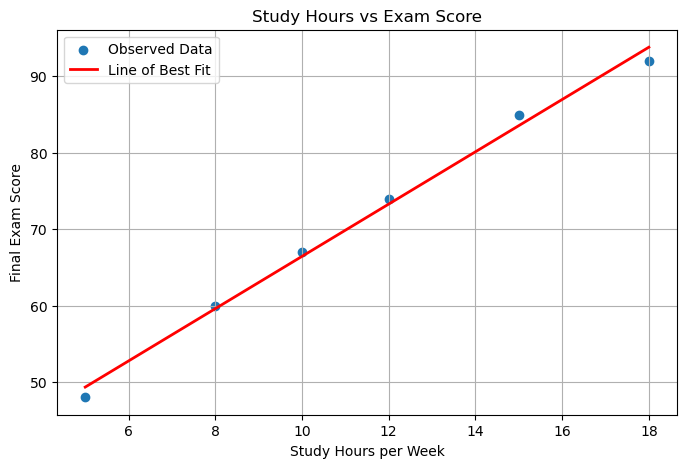

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Data
study_hours = np.array([5, 8, 10, 12, 15, 18])
exam_score = np.array([48, 60, 67, 74, 85, 92])

# Linear regression — find the line of best fit
# Exam Score ≈ a + b × Study Hours
b, a = np.polyfit(study_hours, exam_score, 1)

print(f"Intercept (a): {a:.2f}")
print(f"Slope (b):     {b:.2f}")
print()
print("Model: Exam ≈", round(a,2), "+", round(b,2), "× Study Hours")

# Predicted values on the line
predicted_scores = a + b * study_hours

# Plot
plt.figure(figsize=(8,5))

# Original data points
plt.scatter(study_hours, exam_score, label="Observed Data")

# Best-fit line
plt.plot(
    study_hours,
    predicted_scores,
    'r-',
    linewidth=2,
    label="Line of Best Fit"
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Final Exam Score")
plt.title("Study Hours vs Exam Score")
plt.legend()
plt.grid(True)

plt.show()

What the numbers mean

Intercept a = 32.22 : predicted exam score if a student studied 0 hours
Slope b = 3.42 : for every 1 extra hour of study per week, the exam score increases by 3.42 marks

*The red line on the chart passes as close as possible to all data points simultaneously*.

### Step 6 — Prediction
- **Make a prediction**
  
Use your model to predict a new student's exam score. Then question your own certainty.

In [7]:
# Predict exam score for a new student
new_student_hours = 13

predicted = a + b * new_student_hours

print(f"New student studies: {new_student_hours} hours/week")
print(f"Predicted exam:      {predicted:.1f} marks")

# Quantify our uncertainty
residuals  = [exam_score[i] - (a + b*study_hours[i]) for i in range(len(students))]
rmse       = np.sqrt(np.mean([r**2 for r in residuals]))
print(f"Typical prediction error (RMSE): {rmse:.1f} marks")

New student studies: 13 hours/week
Predicted exam:      76.7 marks
Typical prediction error (RMSE): 1.2 marks


Uncertainty is unavoidable. RMSE tells us the typical error in our predictions. Our model is useful but not perfect : motivation, stress, and health are not captured in the data.

### Step 7 — Action
- **Statistical decision making**
  
Use your analysis to identify at-risk students and make evidence-based recommendations.

In [9]:
# Identify at-risk students
at_risk = []
for i in range(len(students)):
    risk_score = 0
    if study_hours[i] < 9:  risk_score += 1
    if attendance[i]  < 75: risk_score += 1
    if assignment[i]  < 56: risk_score += 1
    pred = a + b * study_hours[i]
    if pred < 60: risk_score += 1
    if risk_score >= 2:
        at_risk.append((students[i], risk_score, pred))

for s, rs, pred in sorted(at_risk, key=lambda x: x[1], reverse=True):
    print(f"Student {s}: risk={rs}/4, predicted exam={pred:.1f}")

Student 1: risk=4/4, predicted exam=49.3
Student 2: risk=2/4, predicted exam=59.6


Statistical decision making: Every recommendation is grounded in evidence — not opinion. The risk score combines multiple signals: study time, attendance, past performance, and model prediction. This is the workflow used in real data science.